<a href="https://colab.research.google.com/github/princealexanderm/-ICT_AI_ML/blob/main/ICT_AI_ML__Assignment_06_Sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICT_AI_ML_ Assignment 06_Sentiment analysis_Prince Alex

Natural language processing has extensively applied in sentiment analysis as a
significant challenge. In this scenario, the objective is to determine if the tweets
shared by customers regarding technology companies that produce and sell
mobiles, computers, laptops, and similar products express positive sentiment or
negative sentiment.
The goal will be to build a system that can accurately classify the new tweets
sentiments. You can divide the data into train and test. The Evaluation metric you
should use is the accuracy.

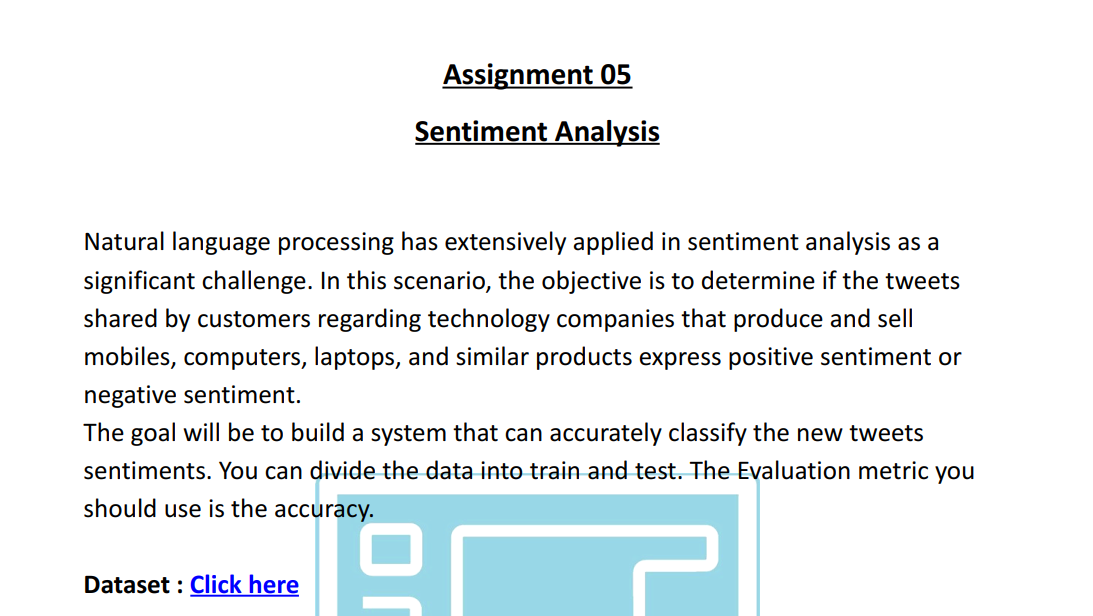

Dataset:https://drive.google.com/file/d/1TiJKt0YgggHMIv5ttw1Z_Cpf9GgExnuH/view

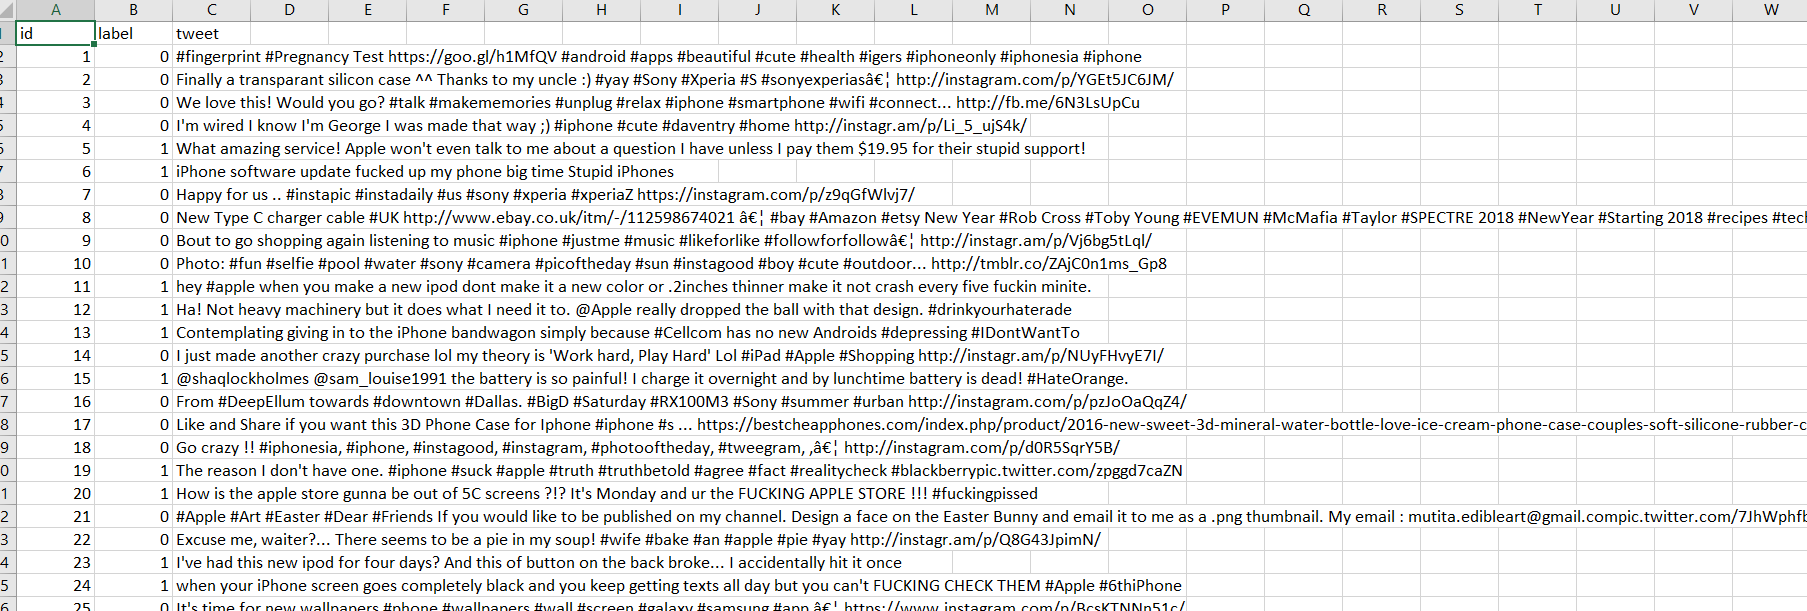

Steps

1. .Load and read Raw Text
2. Tokenization
3. Stopword Removal
4. Stemming or Lemmatization
5. Vectorization
6. ML model input

# 1. import nltk

**1.**Download specific linguistic resources that are required for various natural language processing tasks from Python's Natural Language Toolkit (NLTK).

In [1]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

# 2. Load and read text

In [9]:
import pandas as pd

#
df = pd.read_csv('/content/tweets.csv')
# Extract labels from the second column and reviews from the third column
labels = df.iloc[:, 1].tolist()
tweets = df.iloc[:, 2].tolist()

# Optional: print to check
print("Labels:", labels)
print("tweets:", tweets)

Labels: [0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0

In [10]:
tweets[0]

'#fingerprint #Pregnancy Test https://goo.gl/h1MfQV #android #apps #beautiful #cute #health #igers #iphoneonly #iphonesia #iphone'

In [11]:
tweets[1]

'Finally a transparant silicon case ^^ Thanks to my uncle :) #yay #Sony #Xperia #S #sonyexperias… http://instagram.com/p/YGEt5JC6JM/'

# 3. Text preprocessing

In [12]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

def preprocess_text(text):
  tokens = word_tokenize(text)

  tokens = [word.lower() for word in tokens if word.isalpha()] #remove punctuation

  tokens = [word for word in tokens if word not in stopwords.words('english')] #remove stopwords

  lemmatizer = WordNetLemmatizer()
  tokens = [lemmatizer.lemmatize(word) for word in tokens]
  return ' '.join(tokens)

# 4. Applying preprocessing

In [14]:
processed_tweets = [preprocess_text(tweet) for tweet in tweets]

print(processed_tweets[:3]) #preview the cleaned reviews

['fingerprint pregnancy test http android apps beautiful cute health igers iphoneonly iphonesia iphone', 'finally transparant silicon case thanks uncle yay sony xperia http', 'love would go talk makememories unplug relax iphone smartphone wifi connect http']


# 5.Vectorization + NL Model

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


# all steps upto vectorizing is preprocessing
#vectorize
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(processed_tweets)

# Train-test splits
X_train,X_test,y_train,y_test = train_test_split(X,labels,test_size=0.3, random_state=42)

#Train Classifier
model= LogisticRegression()
model.fit(X_train,y_train)

#predict
y_pred = model.predict(X_test)

#Evaluate
print()

#evaluate
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1735
           1       0.84      0.63      0.72       641

    accuracy                           0.87      2376
   macro avg       0.86      0.79      0.81      2376
weighted avg       0.86      0.87      0.86      2376

